# Part 2 – Python: Building a Reproducible Traffic Analytics Pipeline

## Task 3 – Visualise Traffic Patterns

This section uses Matplotlib to visualise meaningful traffic patterns from the
engineered dataset produced in Task 2.

The visual analysis focuses on:

1. Traffic demand by hour of day
2. Weekday versus weekend traffic patterns
3. Traffic volume under different weather conditions
4. Temperature and traffic relationships

Each figure is saved to disk and accompanied by a short interpretation of the
observed traffic pattern.


In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
engineered_data_path = Path("engineered_traffic_data.csv")

traffic_df = pd.read_csv(
    engineered_data_path,
    parse_dates=["date_time"]
)

traffic_df.shape

(48187, 30)

In [3]:
visualisation_columns = [
    "date_time",
    "traffic_volume",
    "hour",
    "is_weekend",
    "weather_main",
    "temp",
    "congestion_category"
]

traffic_df[visualisation_columns].head()

,date_time,traffic_volume,hour,is_weekend,weather_main,temp,congestion_category
0,2012-10-02 09:00:00,5545,9,0,Clouds,288.28,High
1,2012-10-02 10:00:00,4516,10,0,Clouds,289.36,Medium
2,2012-10-02 11:00:00,4767,11,0,Clouds,289.58,Medium
3,2012-10-02 12:00:00,5026,12,0,Clouds,290.13,High
4,2012-10-02 13:00:00,4918,13,0,Clouds,291.14,Medium


### Task 3.2 – Configure Logging and Figure Output

Logging is configured to provide a traceable record of the visualisation
workflow. Each successfully saved figure is recorded at INFO level together
with its output file path.

All visualisations are saved in a dedicated `figures` directory so that the
generated outputs remain organised and reproducible.

In [4]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

if not logger.handlers:
    formatter = logging.Formatter(
        "%(asctime)s - %(levelname)s - %(name)s - %(message)s"
    )

    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(
        "visualisation.log",
        mode="a"
    )
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

In [5]:
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

logger.info(
    "Visualisation workflow started: %d rows, %d columns. "
    "Figures will be saved to '%s'.",
    traffic_df.shape[0],
    traffic_df.shape[1],
    figures_dir
)

2026-10-06 09:13:21,629 - INFO - __main__ - Visualisation workflow started: 48187 rows, 30 columns. Figures will be saved to 'figures'.


### Task 3.3 – Traffic Demand by Hour

Average traffic volume is calculated for each hour of the day to identify
recurring daily traffic-demand patterns.

A line chart is used because hour represents an ordered time sequence. The
figure is saved to the `figures` directory for reproducibility.

In [6]:
hourly_traffic = (
    traffic_df
    .groupby("hour")["traffic_volume"]
    .mean()
    .sort_index()
)

hourly_traffic

hour
0      834.984774
1      516.339033
2      388.353640
3      371.090864
4      702.551889
5     2094.573437
6     4140.503594
7     4740.181337
8     4587.497115
9     4385.277502
10    4184.135838
11    4465.569231
12    4718.031730
13    4714.652836
14    4931.888776
15    5240.459907
16    5663.756539
17    5310.076048
18    4263.563792
19    3275.206438
20    2834.667509
21    2668.940464
22    2199.405717
23    1469.135294
Name: traffic_volume, dtype: float64

2026-10-06 09:13:22,896 - INFO - __main__ - Figure saved successfully to 'figures\traffic_by_hour.png'.


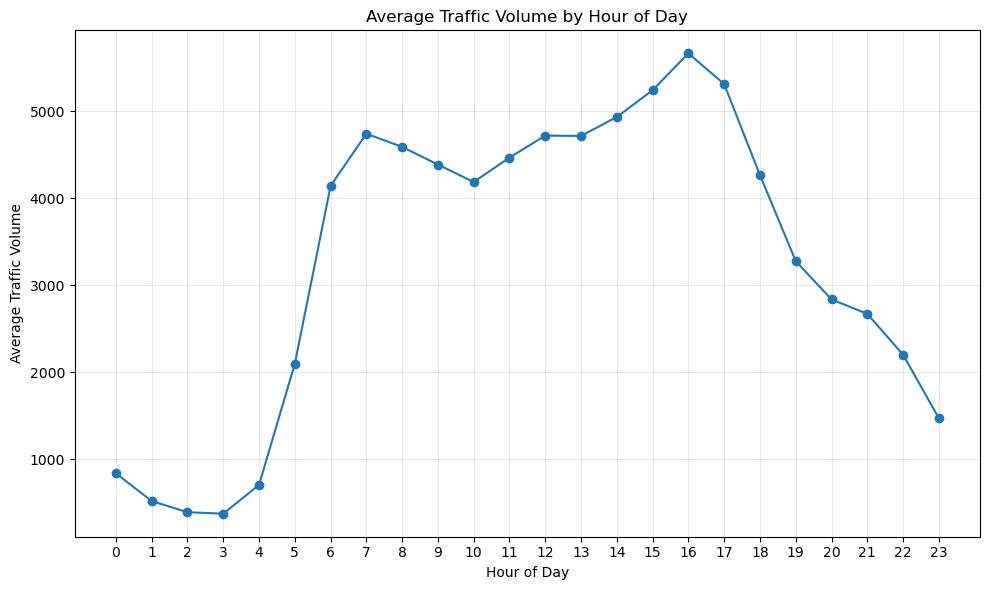

In [7]:
figure_path = figures_dir / "traffic_by_hour.png"

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

logger.info(
    "Figure saved successfully to '%s'.",
    figure_path
)

plt.show()
plt.close()

**Interpretation:** Average traffic volume is lowest during the early-morning
hours, reaching approximately 371 vehicles at 03:00. Traffic demand rises
sharply from 05:00 and reaches about 4,740 vehicles at 07:00, indicating a
clear morning commuting period.

Traffic remains relatively high throughout the daytime and reaches its highest
average level at approximately 5,664 vehicles at 16:00. After 17:00, traffic
volume declines progressively into the evening. Overall, the pattern shows
distinct morning and afternoon commuting demand, with the afternoon peak
higher than the morning peak.

### Task 3.4 – Weekday vs Weekend Traffic

Average traffic volume is compared between weekdays and weekends across each
hour of the day.

This comparison helps identify how commuting and travel patterns differ between
working days and weekends.

In [8]:
weekday_weekend_traffic = (
    traffic_df
    .groupby(["hour", "is_weekend"])["traffic_volume"]
    .mean()
    .unstack()
)

weekday_weekend_traffic.columns = [
    "Weekday",
    "Weekend"
]

weekday_weekend_traffic

,Weekday,Weekend
hour,,
0,651.686903,1306.414035
1,396.913043,805.717391
2,301.982818,611.171986
3,362.289835,393.611599
4,832.661096,375.420168
5,2701.296703,639.237232
6,5365.983210,1089.100334
7,6030.413559,1589.365894
8,5503.497970,2338.578073


2026-10-06 09:13:24,390 - INFO - __main__ - Figure saved successfully to 'figures\weekday_vs_weekend.png'.


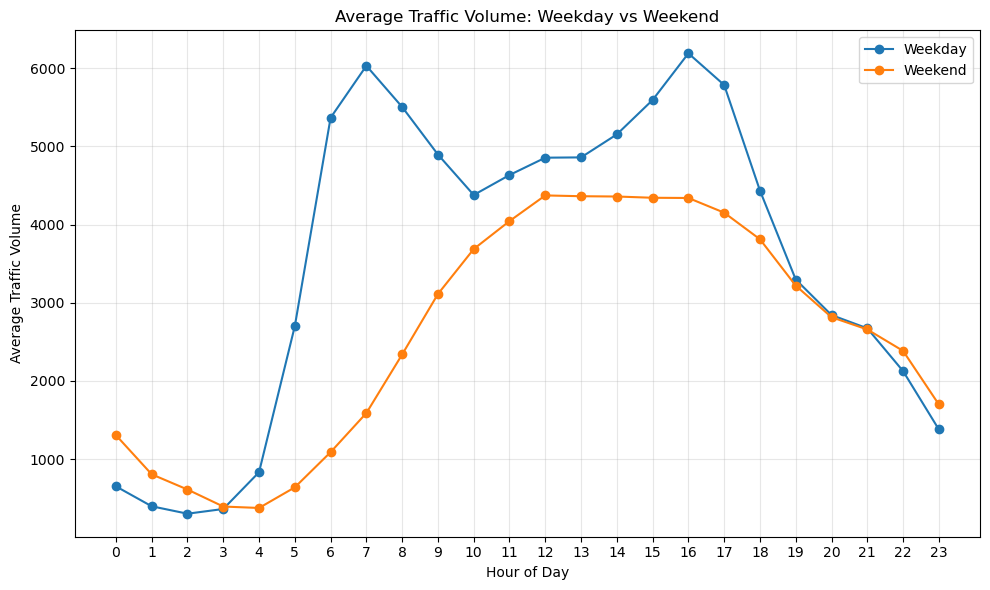

In [9]:
figure_path = figures_dir / "weekday_vs_weekend.png"

plt.figure(figsize=(10, 6))

plt.plot(
    weekday_weekend_traffic.index,
    weekday_weekend_traffic["Weekday"],
    marker="o",
    label="Weekday"
)

plt.plot(
    weekday_weekend_traffic.index,
    weekday_weekend_traffic["Weekend"],
    marker="o",
    label="Weekend"
)

plt.title("Average Traffic Volume: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

logger.info(
    "Figure saved successfully to '%s'.",
    figure_path
)

plt.show()
plt.close()

### Task 3.5 – Traffic by Weather Condition

Average traffic volume is compared across the main weather conditions to examine
whether traffic demand differs under different types of weather.

The number of observations in each weather category is also examined before
interpreting the averages, because categories with very few observations may
produce less representative results.

In [10]:
weather_summary = (
    traffic_df
    .groupby("weather_main")["traffic_volume"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

weather_summary

,mean,count
weather_main,,
Clouds,3617.989115,15158
Haze,3502.101471,1360
Rain,3317.905501,5672
Drizzle,3292.189560,1820
Smoke,3237.650000,20
Clear,3055.614465,13384
Snow,3016.321391,2875
Thunderstorm,2999.431752,1033
Mist,2933.343923,5949


2026-10-06 09:13:25,719 - INFO - __main__ - Figure saved successfully to 'figures\traffic_by_weather.png'.


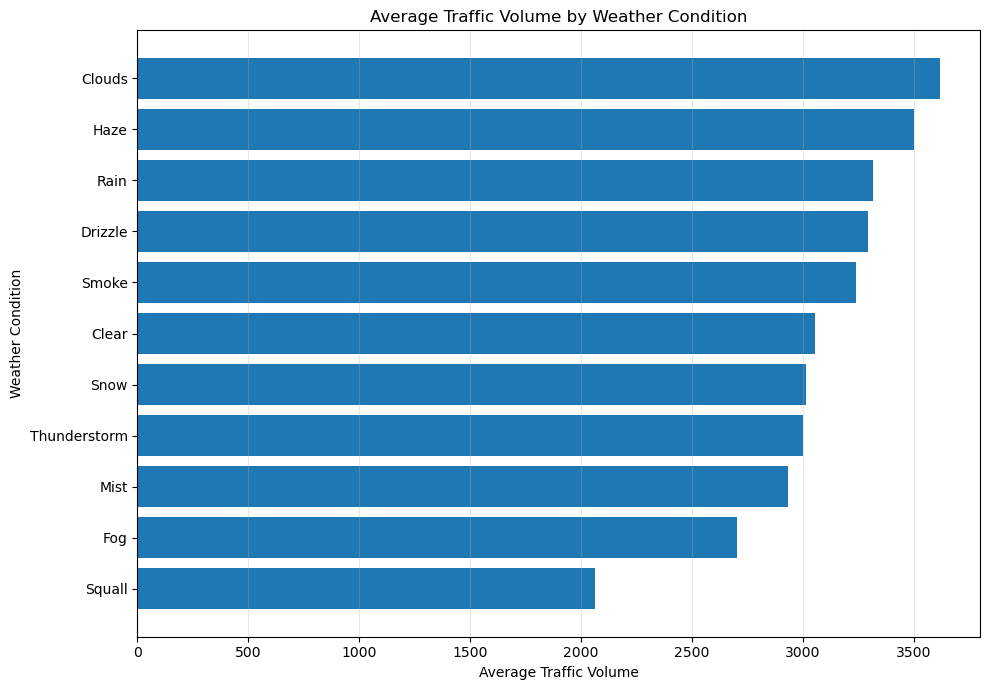

In [11]:
figure_path = figures_dir / "traffic_by_weather.png"

weather_plot_data = weather_summary.sort_values(
    "mean",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    weather_plot_data.index,
    weather_plot_data["mean"]
)

plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Average Traffic Volume")
plt.ylabel("Weather Condition")
plt.grid(
    axis="x",
    alpha=0.3
)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

logger.info(
    "Figure saved successfully to '%s'.",
    figure_path
)

plt.show()
plt.close()

**Interpretation:** Average traffic volume varies across weather conditions.
Among categories with substantial numbers of observations, `Clouds` has the
highest average traffic volume at approximately 3,618 vehicles, followed by
`Haze` at about 3,502 and `Rain` at about 3,318.

`Clear` conditions average approximately 3,056 vehicles, while `Mist` and
`Fog` show lower averages of approximately 2,933 and 2,704 respectively.
These results indicate an association between weather category and observed
traffic demand, but they do not establish that weather itself causes the
differences.

The `Smoke` and `Squall` categories should be interpreted cautiously because
they contain only 20 and 4 observations respectively, making their average
traffic volumes less representative than categories with larger sample sizes.

2026-10-06 09:13:29,327 - INFO - __main__ - Figure saved successfully to 'figures\temperature_vs_traffic.png'.


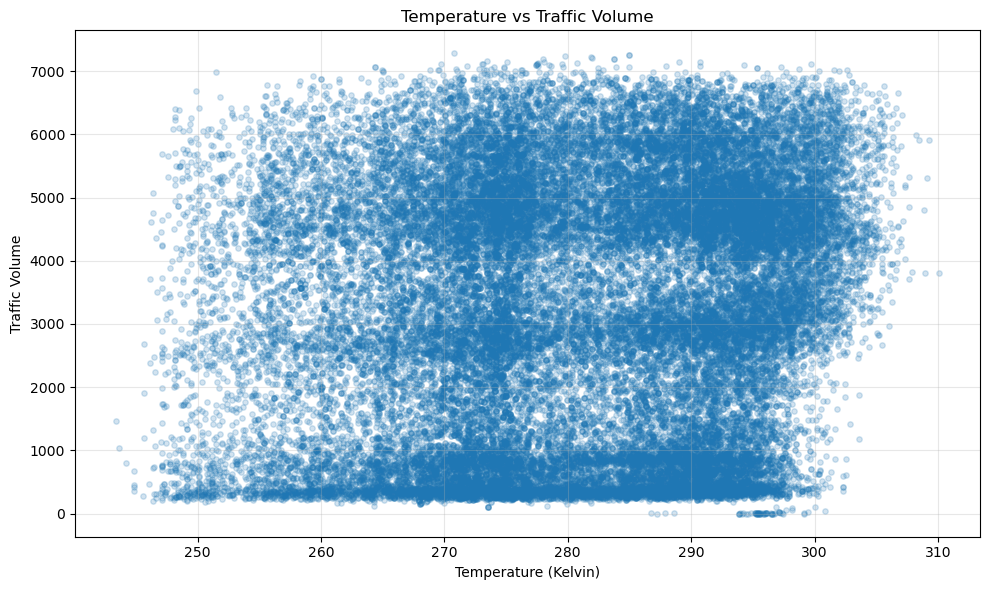

In [12]:
figure_path = figures_dir / "temperature_vs_traffic.png"

plt.figure(figsize=(10, 6))

plt.scatter(
    traffic_df["temp"],
    traffic_df["traffic_volume"],
    alpha=0.2,
    s=15
)

plt.title("Temperature vs Traffic Volume")
plt.xlabel("Temperature (Kelvin)")
plt.ylabel("Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

logger.info(
    "Figure saved successfully to '%s'.",
    figure_path
)

plt.show()
plt.close()

**Interpretation:** The scatter plot does not show a strong or simple linear
relationship between temperature and traffic volume. At most temperatures,
traffic volume varies widely from relatively low levels to more than 6,000
vehicles.

Higher traffic volumes are observed across a broad temperature range,
particularly around 260–300 K, rather than being concentrated at one specific
temperature. This suggests that temperature alone is unlikely to explain the
variation in traffic demand.

A small number of observations show unusually low traffic volumes, including
values close to zero around the warmer temperature range. Overall, other
factors such as hour of day, weekday/weekend status, and travel behaviour are
likely to be more important for explaining traffic-volume patterns.

### Task 3.7 – Validate Saved Visualisations

The expected visualisation files are checked to confirm that all figures were
successfully written to disk.

This provides a final validation step before the visualisation workflow is
converted into a reproducible Python script.

In [13]:
expected_figures = [
    figures_dir / "traffic_by_hour.png",
    figures_dir / "weekday_vs_weekend.png",
    figures_dir / "traffic_by_weather.png",
    figures_dir / "temperature_vs_traffic.png"
]

for figure in expected_figures:
    if figure.exists():
        logger.info(
            "Validated saved figure: '%s'.",
            figure
        )
    else:
        logger.error(
            "Expected figure was not found: '%s'.",
            figure
        )

2026-10-06 09:13:29,881 - INFO - __main__ - Validated saved figure: 'figures\traffic_by_hour.png'.
2026-10-06 09:13:29,885 - INFO - __main__ - Validated saved figure: 'figures\weekday_vs_weekend.png'.
2026-10-06 09:13:29,886 - INFO - __main__ - Validated saved figure: 'figures\traffic_by_weather.png'.
2026-10-06 09:13:29,890 - INFO - __main__ - Validated saved figure: 'figures\temperature_vs_traffic.png'.


In [14]:
all_figures_saved = all(
    figure.exists()
    for figure in expected_figures
)

all_figures_saved

True